In [6]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from data_load import load_opencarp_2d_voltage
from model import MLP_Net


In [10]:
# --------------------------------------------------
# Load data and checkpoint
# --------------------------------------------------

data = load_opencarp_2d_voltage(
    vm_path="openCARP-PINNs/Data/MS/Single_Corner/vm.igb",
    pts_path="openCARP-PINNs/Data/MS/Mesh/block",
    dt=1.0,
    z_slice="middle",
)

ckpt_path = Path("outputs/mlp_data_only_256.pt")
ckpt = torch.load(ckpt_path, map_location="cpu")

model = MLP_Net(hidden_widths=ckpt["hidden_widths"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

print("Loaded checkpoint:", ckpt_path)
print("Checkpoint epoch:", ckpt.get("epoch"))
print("Checkpoint test_mse:", ckpt.get("test_mse"))
print("vm shape:", data.vm.shape)


Loaded checkpoint: outputs/mlp_data_only_256.pt
Checkpoint epoch: 288
Checkpoint test_mse: 0.037583193303726475
vm shape: (101, 11, 101)


In [11]:
# --------------------------------------------------
# Predict on full grid
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

coords = torch.from_numpy(data.coords_norm).float()
pred_chunks = []

batch_size = 65536

with torch.no_grad():
    for i in range(0, coords.shape[0], batch_size):
        batch = coords[i:i + batch_size].to(device)
        pred = model(batch)[:, 0:1].cpu().numpy()
        pred_chunks.append(pred)

vm_pred_flat = np.vstack(pred_chunks)
vm_pred = vm_pred_flat.reshape(data.vm.shape)

vm_true = data.vm
vm_error = vm_pred - vm_true

print("prediction shape:", vm_pred.shape)
print("true range:", np.nanmin(vm_true), np.nanmax(vm_true))
print("pred range:", np.nanmin(vm_pred), np.nanmax(vm_pred))
print("RMSE:", np.sqrt(np.mean(vm_error**2)))


prediction shape: (101, 11, 101)
true range: 0.0 0.93377805
pred range: 0.024684157 0.936387
RMSE: 0.19443373


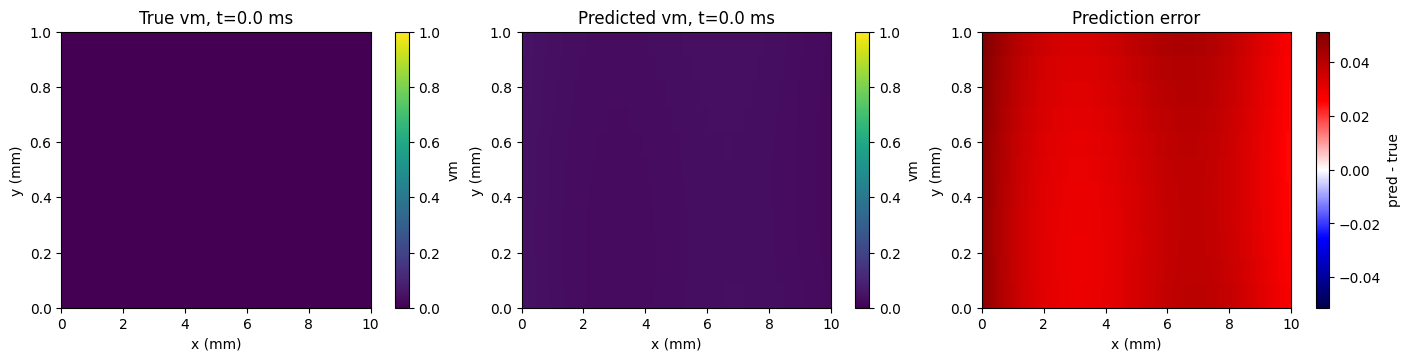

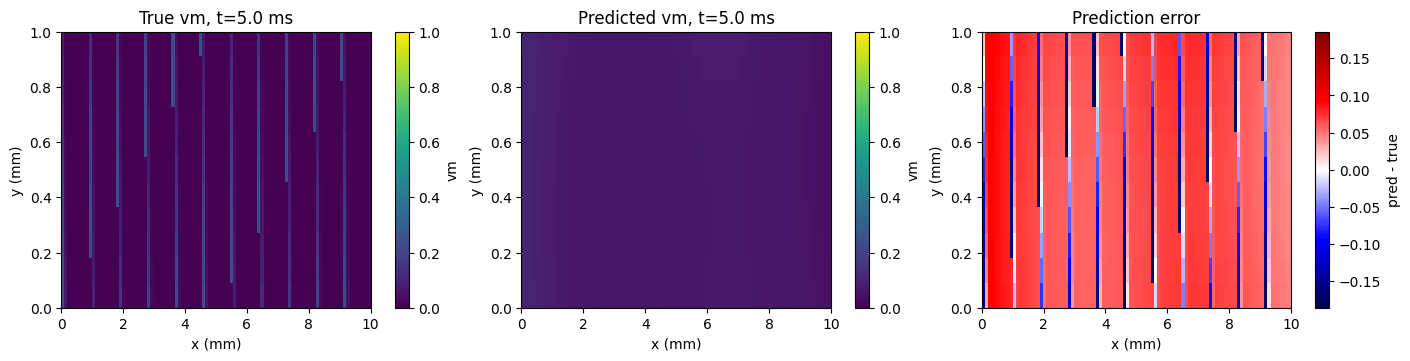

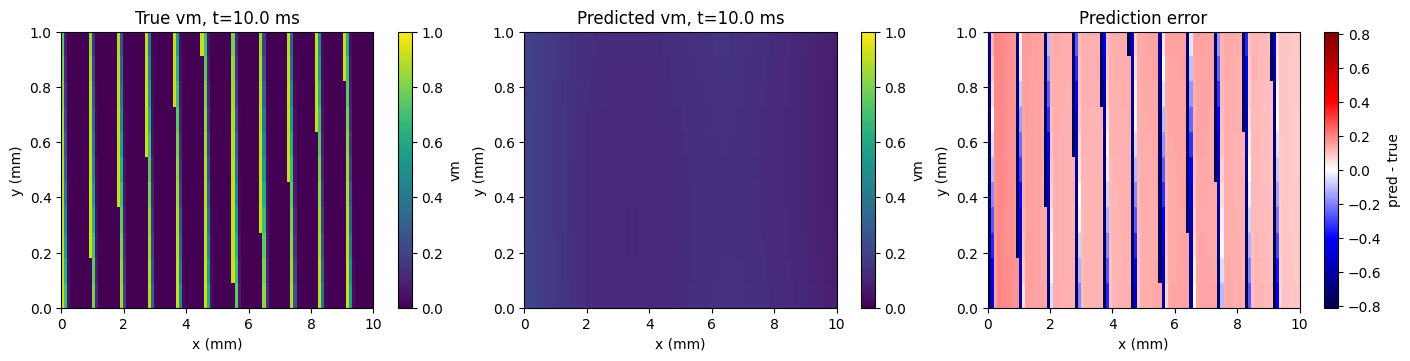

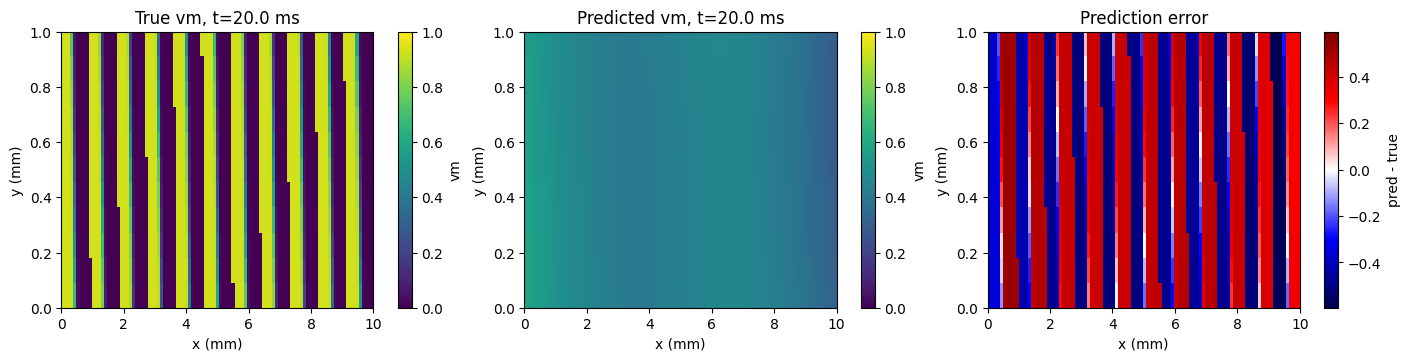

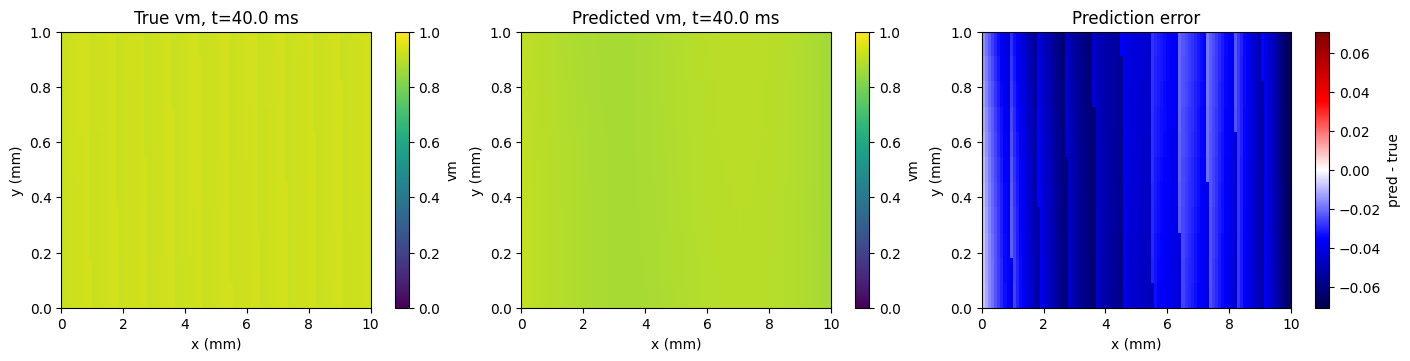

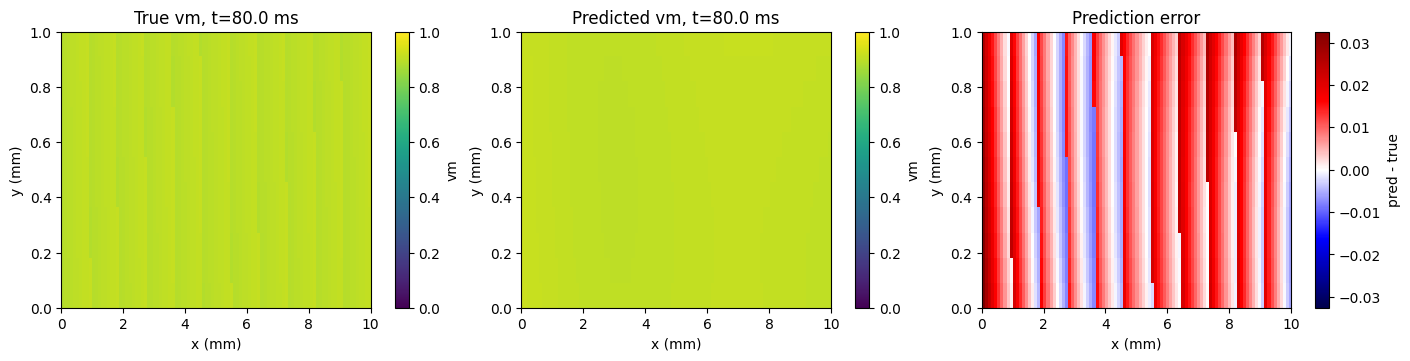

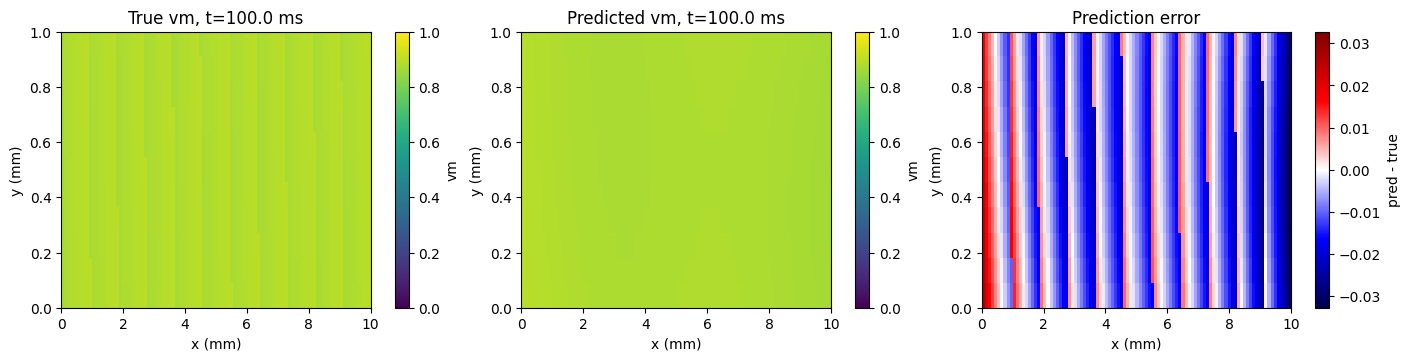

In [12]:
# --------------------------------------------------
# True vs predicted snapshots + error maps
# --------------------------------------------------

frame_ids = [0, 5, 10, 20, 40, 80, 100]
frame_ids = [i for i in frame_ids if i < data.vm.shape[2]]

for tidx in frame_ids:
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)

    im0 = axes[0].imshow(
        vm_true[:, :, tidx].T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        extent=[data.bounds["x_min"], data.bounds["x_max"], data.bounds["y_min"], data.bounds["y_max"]],
    )
    axes[0].set_title(f"True vm, t={data.t[tidx]:.1f} ms")
    axes[0].set_xlabel("x (mm)")
    axes[0].set_ylabel("y (mm)")
    fig.colorbar(im0, ax=axes[0], label="vm")

    im1 = axes[1].imshow(
        vm_pred[:, :, tidx].T,
        origin="lower",
        aspect="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        extent=[data.bounds["x_min"], data.bounds["x_max"], data.bounds["y_min"], data.bounds["y_max"]],
    )
    axes[1].set_title(f"Predicted vm, t={data.t[tidx]:.1f} ms")
    axes[1].set_xlabel("x (mm)")
    axes[1].set_ylabel("y (mm)")
    fig.colorbar(im1, ax=axes[1], label="vm")

    vmax_err = np.nanmax(np.abs(vm_error[:, :, tidx]))
    im2 = axes[2].imshow(
        vm_error[:, :, tidx].T,
        origin="lower",
        aspect="auto",
        cmap="seismic",
        vmin=-vmax_err,
        vmax=vmax_err,
        extent=[data.bounds["x_min"], data.bounds["x_max"], data.bounds["y_min"], data.bounds["y_max"]],
    )
    axes[2].set_title("Prediction error")
    axes[2].set_xlabel("x (mm)")
    axes[2].set_ylabel("y (mm)")
    fig.colorbar(im2, ax=axes[2], label="pred - true")

    plt.show()
